In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.model_selection as skm
import time
from xgbsearch import XgbGridSearch
from itertools import product
from scipy.stats import uniform, randint


from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)

from sklearn.metrics import (accuracy_score, log_loss, roc_curve,
                              roc_auc_score, classification_report,
                              confusion_matrix, f1_score, matthews_corrcoef)

from sklearn.ensemble import (RandomForestRegressor as RF,
                               RandomForestClassifier as RFC)

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (cross_val_score, GridSearchCV,
                                      StratifiedKFold, RandomizedSearchCV)
from sklearn.calibration import calibration_curve
from scipy.stats import uniform, randint

from matplotlib.pyplot import subplots
from ISLP import load_data

import xgboost as xgb

okabe_ito = {
    "orange":    "#E69F00",
    "sky_blue":  "#56B4E9",
    "green":     "#009E73",
    "yellow":    "#F0E442",
    "blue":      "#0072B2",
    "vermilion": "#D55E00",
    "pink":      "#CC79A7",
    "black":     "#000000",
}

oi_colors = list(okabe_ito.values())

In [5]:

taiwan_credit = pd.read_csv("/home/georgehagstrom/work/Teaching/DATA622Spring2026/website/meetups/meetup-9/UCI_Credit_Card.csv")


X = taiwan_credit.drop(columns=["ID", "default.payment.next.month"])
y = taiwan_credit["default.payment.next.month"]

feature_names = list(X.columns)
class_names = ["No Default", "Default"]


X_train, X_test, y_train, y_test = skm.train_test_split(
    X, y, test_size=0.2, random_state=1001, stratify=y
)


In [6]:

correlations = X_train.corrwith(y_train)
corr_top= correlations.abs().sort_values(ascending=False).head(15)
corr_top_s = correlations[corr_top.index].to_frame(name="correlation")
corr_top_s.head(15)



,correlation
PAY_0,0.327770
PAY_2,0.263590
PAY_3,0.235160
PAY_4,0.218304
PAY_5,0.206920
PAY_6,0.188902
LIMIT_BAL,-0.155912
PAY_AMT1,-0.070510
PAY_AMT5,-0.056307
PAY_AMT2,-0.055253


In [ ]:

# Let's fit an xgboost model, using cross validation to pick the learning rate
# and early stopping

# Here is our vector of learning rates

learning_rates = [0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.3]

# dtrain is the xgboost data structure which is necessary here

dtrain = xgb.DMatrix(X_train, label=y_train)

# blank array for the results

results = []

# We do our hyperparameter optimization loop. Why couldn't we do grid search in the standard sklearn way?

# Problem is that GridSearch doesn't have a natural way that I know of to automatically supply
# the evaluation set. So what happens is you would have to supply in the 
# XGBClassifier fit params {"eval_set":something}, but you want the something to be the held out part
# of the CV folds, but if you set the something in the XGBClassifier it will be the same. If you put
# the test set there then you will have data leakage, if you pick out a separate hold out set you are
# wasting data. Hence you use a loop by hand and use xgb library internal cv






for lr in learning_rates:
    # Note that the xgboost library has its own cross-validation
    cv_results = xgb.cv(

        # If this was an xgbclassifier with early stopping we would have to provide an eval_set, but
        #xgb.cv handles this internally
        params={
            "max_depth": 3, # Default is 6 could also tune this
            "learning_rate": lr, 
            "objective": "binary:logistic" # Letting it know that there is a binary target 
        },
        dtrain=dtrain,
        num_boost_round=5000,
        nfold=5, # Default is 3
        early_stopping_rounds=50, # How long to go without improvement
        seed=10
    )

    # Save the details of early stopping

    results.append({
        "learning_rate": lr,
        "cv_logloss": cv_results["test-logloss-mean"].min(),
        "n_trees": cv_results.shape[0],
    })


# get a nice data frame
results_df = pd.DataFrame(results)

In [7]:
results_df

,learning_rate,cv_logloss,n_trees
0,0.005,0.427385,1903
1,0.010,0.427322,1015
2,0.025,0.427346,386
3,0.050,0.427167,230
4,0.100,0.427270,118
5,0.200,0.427409,55
6,0.300,0.428350,33


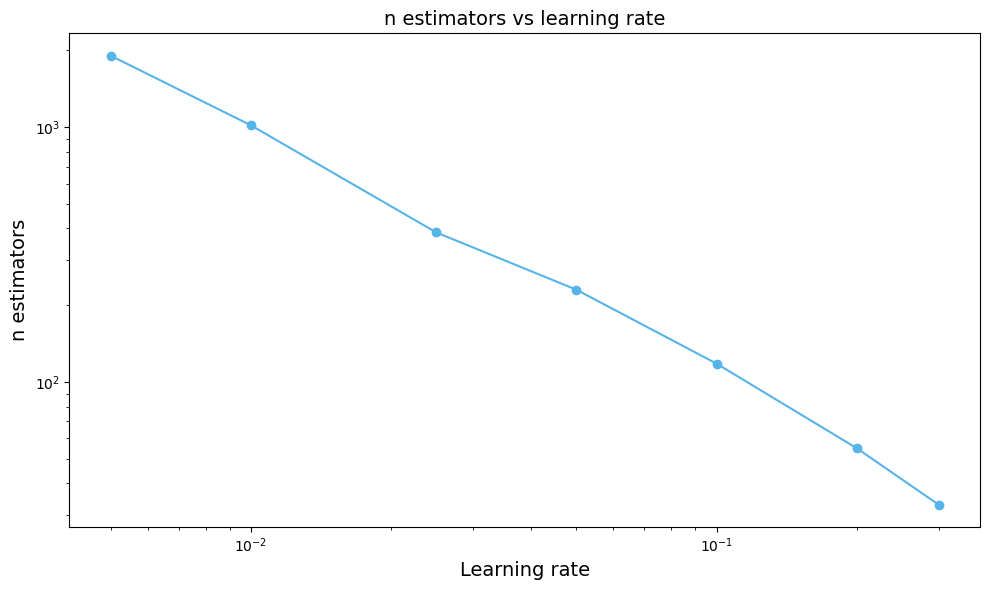

In [8]:

fig, ax = plt.subplots(figsize=(10, 6))



# Right: n_trees vs learning rate
ax.plot(results_df["learning_rate"], results_df["n_trees"], "o-", color=oi_colors[1])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Learning rate", fontsize=14)
ax.set_ylabel("n estimators", fontsize=14)
ax.set_title("n estimators vs learning rate", fontsize=14)

plt.tight_layout()


In [24]:

best_row = results_df.loc[results_df['cv_logloss'].idxmin()]

# We have found the best hyperparameter values, now we are going to train the final model using that
# value of the hyperparameters, but to do the early stopping we have to split off a small validation
# set, so we do a train-test split on the training set and use X_es and y_es for deciding when to stop


X_sub, X_es, y_sub, y_es = skm.train_test_split(
    X_train, y_train, test_size=0.15, random_state=1111, stratify=y_train
)

# Setup our classifier

final_model = xgb.XGBClassifier(
    n_estimators=5000,
    max_depth=3,
    learning_rate=best_row['learning_rate'],
    early_stopping_rounds=50,
    eval_metric='logloss',
    random_state=30,
    verbosity=0
)

# Fit it, you don't need the verbosity parameter but it will print a lot of output 
# without it. Could be convenient if it takes a long time

final_model.fit(X_sub, y_sub, eval_set=[(X_es, y_es)],verbose=False)


# Alright let's spin up some very basic models for comparison, this is
# probably unfair because we haven't tuned them

rf = RFC(
    n_estimators=500,
    random_state=999
)
rf.fit(X_train, y_train)


lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=10000, random_state=31, penalty=None)),
])
lr_model.fit(X_train, y_train)

lr_probs = lr_model.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

print(f"{'Model':<25} {'Log Loss':>10} {'Accuracy':>10}")
print("-" * 47)
print(f"{'XGBoost':<25} {log_loss(y_test, final_model.predict_proba(X_test)):>10.4f} {accuracy_score(y_test, final_model.predict(X_test)):>10.4f}")
print(f"{'Random Forest':<25} {log_loss(y_test, rf.predict_proba(X_test)):>10.4f} {accuracy_score(y_test, rf.predict(X_test)):>10.4f}")
print(f"{'Logistic Regression':<25} {log_loss(y_test, lr_model.predict_proba(X_test)):>10.4f} {accuracy_score(y_test, lr_model.predict(X_test)):>10.4f}")


/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Model                       Log Loss   Accuracy
-----------------------------------------------
XGBoost                       0.4335     0.8195
Random Forest                 0.4423     0.8158
Logistic Regression           0.4679     0.8113


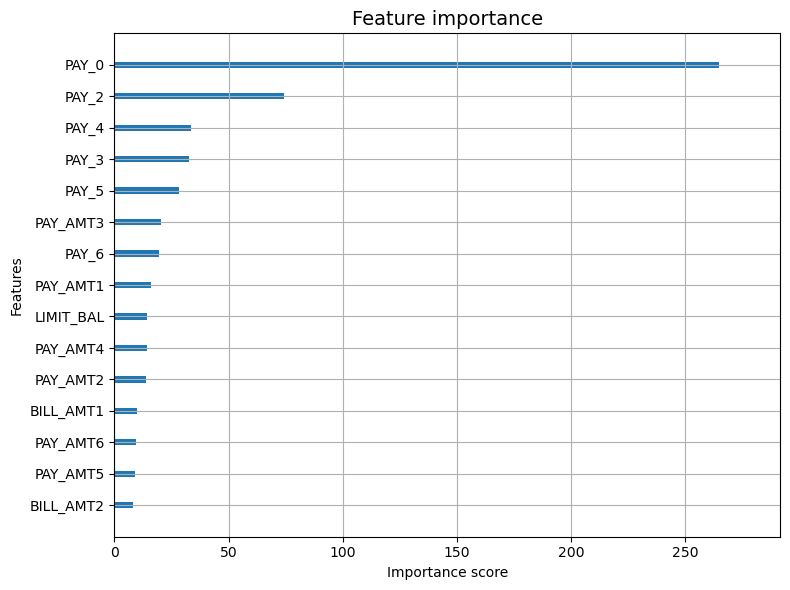

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
xgb.plot_importance(final_model, ax=ax, max_num_features=15,
                     importance_type='gain', show_values=False)
ax.set_title('Feature importance', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Now let's expand our CV search to a 2D grid, you can see 
# How this is just going to get dramatically harder as the number of points
# goes up


# We will be combining these parameters

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
}

#kf = skm.KFold(n_splits=5, shuffle=True, random_state=7)


cv_records = []

for combo in product(*param_grid.values()): # This is a bit of flashy code that combines the parameters
    # in param grid in a product format with all the possible combos, then creates a dict 
    # with the parameters of the loop iteration
    params = dict(zip(param_grid.keys(), combo))

    dtrain = xgb.DMatrix(X_train, label=y_train)

    cv_results = xgb.cv(
        params={
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "learning_rate": params["learning_rate"],
            "max_depth": params["max_depth"], # if you want to be flashy you could put **params here
        },
        dtrain=dtrain,
        num_boost_round=5000,
        nfold=5,
        early_stopping_rounds=50,
        seed=3,
        verbose_eval=False,
    )

   cv_records.append({**params,
                   "cv_logloss":cv_results["test-logloss-mean"].min(),
                   "n_trees":cv_results.shape[0]
    })



cv_df = pd.DataFrame(cv_records)

print(cv_df.sort_values('cv_logloss').head(10).to_string(index=False))



Top 10 parameter combinations by CV log loss:
 max_depth  learning_rate  cv_logloss  mean_trees
         4           0.01    0.426806         715
         4           0.05    0.426870         133
         4           0.10    0.426901          63
         5           0.01    0.426978         551
         5           0.05    0.427085         110
         3           0.01    0.427095        1152
         3           0.05    0.427188         193
         3           0.10    0.427291         110
         6           0.01    0.427435         383
         6           0.05    0.427657          69


NameError: name 'best_params' is not defined

In [17]:
best_row = cv_df.sort_values('cv_logloss').iloc[0]
best_params = {
    "max_depth": int(best_row["max_depth"]),
    "learning_rate": best_row["learning_rate"],
}
print(f"Best params: {best_params}")

Best params: {'max_depth': 4, 'learning_rate': np.float64(0.01)}


In [18]:
final_tuned = xgb.XGBClassifier(
    n_estimators=5000,
    early_stopping_rounds=50,
    eval_metric='logloss',
    verbosity=0,
    random_state=91,
    **best_params,
)
final_tuned.fit(X_sub, y_sub, eval_set=[(X_es, y_es)], verbose=False)

print(f'Trees used: {final_tuned.best_iteration}')
print(f'Test log loss: {log_loss(y_test, final_tuned.predict_proba(X_test)):.4f}')
print(f'Test accuracy: {accuracy_score(y_test, final_tuned.predict(X_test)):.4f}')


Trees used: 655
Test log loss: 0.4331
Test accuracy: 0.8213


In [26]:
n_iter = 5
rng = np.random.default_rng(413242)
dtrain = xgb.DMatrix(X_train, label=y_train)

results = []

for i in range(n_iter):
    params = {
        "max_depth": (rng.integers(3, 9)),
        "learning_rate": (10 ** rng.uniform(-2, np.log10(0.3))),
        "subsample": (rng.uniform(0.5, 1.0)),
        "colsample_bytree": (rng.uniform(0.5, 1.0)),
        "min_child_weight": (rng.choice([1, 3, 5, 7])),
        "reg_lambda": (10 ** rng.uniform(-2, 1)),
    }

    cv_results = xgb.cv(
        params={
            "objective": "binary:logistic",
            **params,
        },
        dtrain=dtrain,
        num_boost_round=5000,
        nfold=5,
        early_stopping_rounds=50,
        seed=879,
        verbose_eval=False,
    )

    results.append({
        **params,
        "cv_logloss": cv_results["test-logloss-mean"].min(),
        "mean_trees": cv_results.shape[0],
    })

results_df = pd.DataFrame(results).sort_values("cv_logloss")
print(results_df.head(10).to_string(index=False))

 max_depth  learning_rate  subsample  colsample_bytree  min_child_weight  reg_lambda  cv_logloss  mean_trees
         4       0.016175   0.528900          0.601385                 7    0.054291    0.425596         500
         6       0.129661   0.827261          0.621068                 7    0.013559    0.426193          33
         7       0.055251   0.648638          0.655019                 3    4.695765    0.426534          92
         8       0.018311   0.921960          0.720151                 5    1.485971    0.426723         207
         6       0.183912   0.734501          0.889181                 3    0.052151    0.429983          20


In [21]:
best_row_rs = results_df.iloc[0]
rs_params = {
    "max_depth": int(best_row_rs["max_depth"]),
    "learning_rate": best_row_rs["learning_rate"],
    "subsample": best_row_rs["subsample"],
    "colsample_bytree": best_row_rs["colsample_bytree"],
    "min_child_weight": int(best_row_rs["min_child_weight"]),
    "reg_lambda": best_row_rs["reg_lambda"],
}

rs_final = xgb.XGBClassifier(
    n_estimators=5000,
    early_stopping_rounds=50,
    eval_metric='logloss',
    verbosity=0,
    random_state=300,
    **rs_params,
)
rs_final.fit(X_sub, y_sub, eval_set=[(X_es, y_es)], verbose=False)

print(f'Trees used: {rs_final.best_iteration}')
print(f'Test log loss: {log_loss(y_test, rs_final.predict_proba(X_test)):.4f}')
print(f'Test accuracy: {accuracy_score(y_test, rs_final.predict(X_test)):.4f}')

Trees used: 298
Test log loss: 0.4312
Test accuracy: 0.8205


In [23]:
models = {
    'XGB LR Tune': final_model,
    'XGB 2D Grid': final_tuned,
    'XGB Random Search': rs_final,
    'Random Forest': rf,
    'Logistic Regression': lr_model,
}

print(f"{'Model':<30} {'Log Loss':>10} {'Accuracy':>10} {'AUC':>10}")

for name, m in models.items():
    probs = m.predict_proba(X_test)
    preds = m.predict(X_test)
    ll = log_loss(y_test, probs)
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs[:, 1])
    print(f'{name:<30} {ll:>10.4f} {acc:>10.4f} {auc:>10.4f}')


Model                            Log Loss   Accuracy        AUC
XGB LR Tune                        0.4337     0.8200     0.7691
XGB 2D Grid                        0.4331     0.8213     0.7705
XGB Random Search                  0.4312     0.8205     0.7732
Random Forest                      0.4423     0.8158     0.7594
Logistic Regression                0.4679     0.8113     0.7149
